<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/GPU_Accelerated_Monte_Carlo_Simulation_of_the_Probability_of_Campus_Biodome_for_UMN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

CUDA device              : NVIDIA L4
GPU memory free / total : 20.50 / 22.03 GiB
CuPy version             : 14.0.1
CuPy RNG backend          : RandomState [PASS]

Simulation configuration
Monte Carlo trials              : 250,000
Sensitivity trials              : 60,000
Time step                       : 20 years
Simulation horizon              : 10,000 years
Yellowstone annual scenario rate: 1.370e-06
Smoke regime step               : 20 years

Architecture summary
         architecture   p_1500  p_10000  median_completion_year
distributed_biocanopy 0.160140  0.97336             2753.372559
     monolithic_shell 0.005108  0.27490             5566.169922


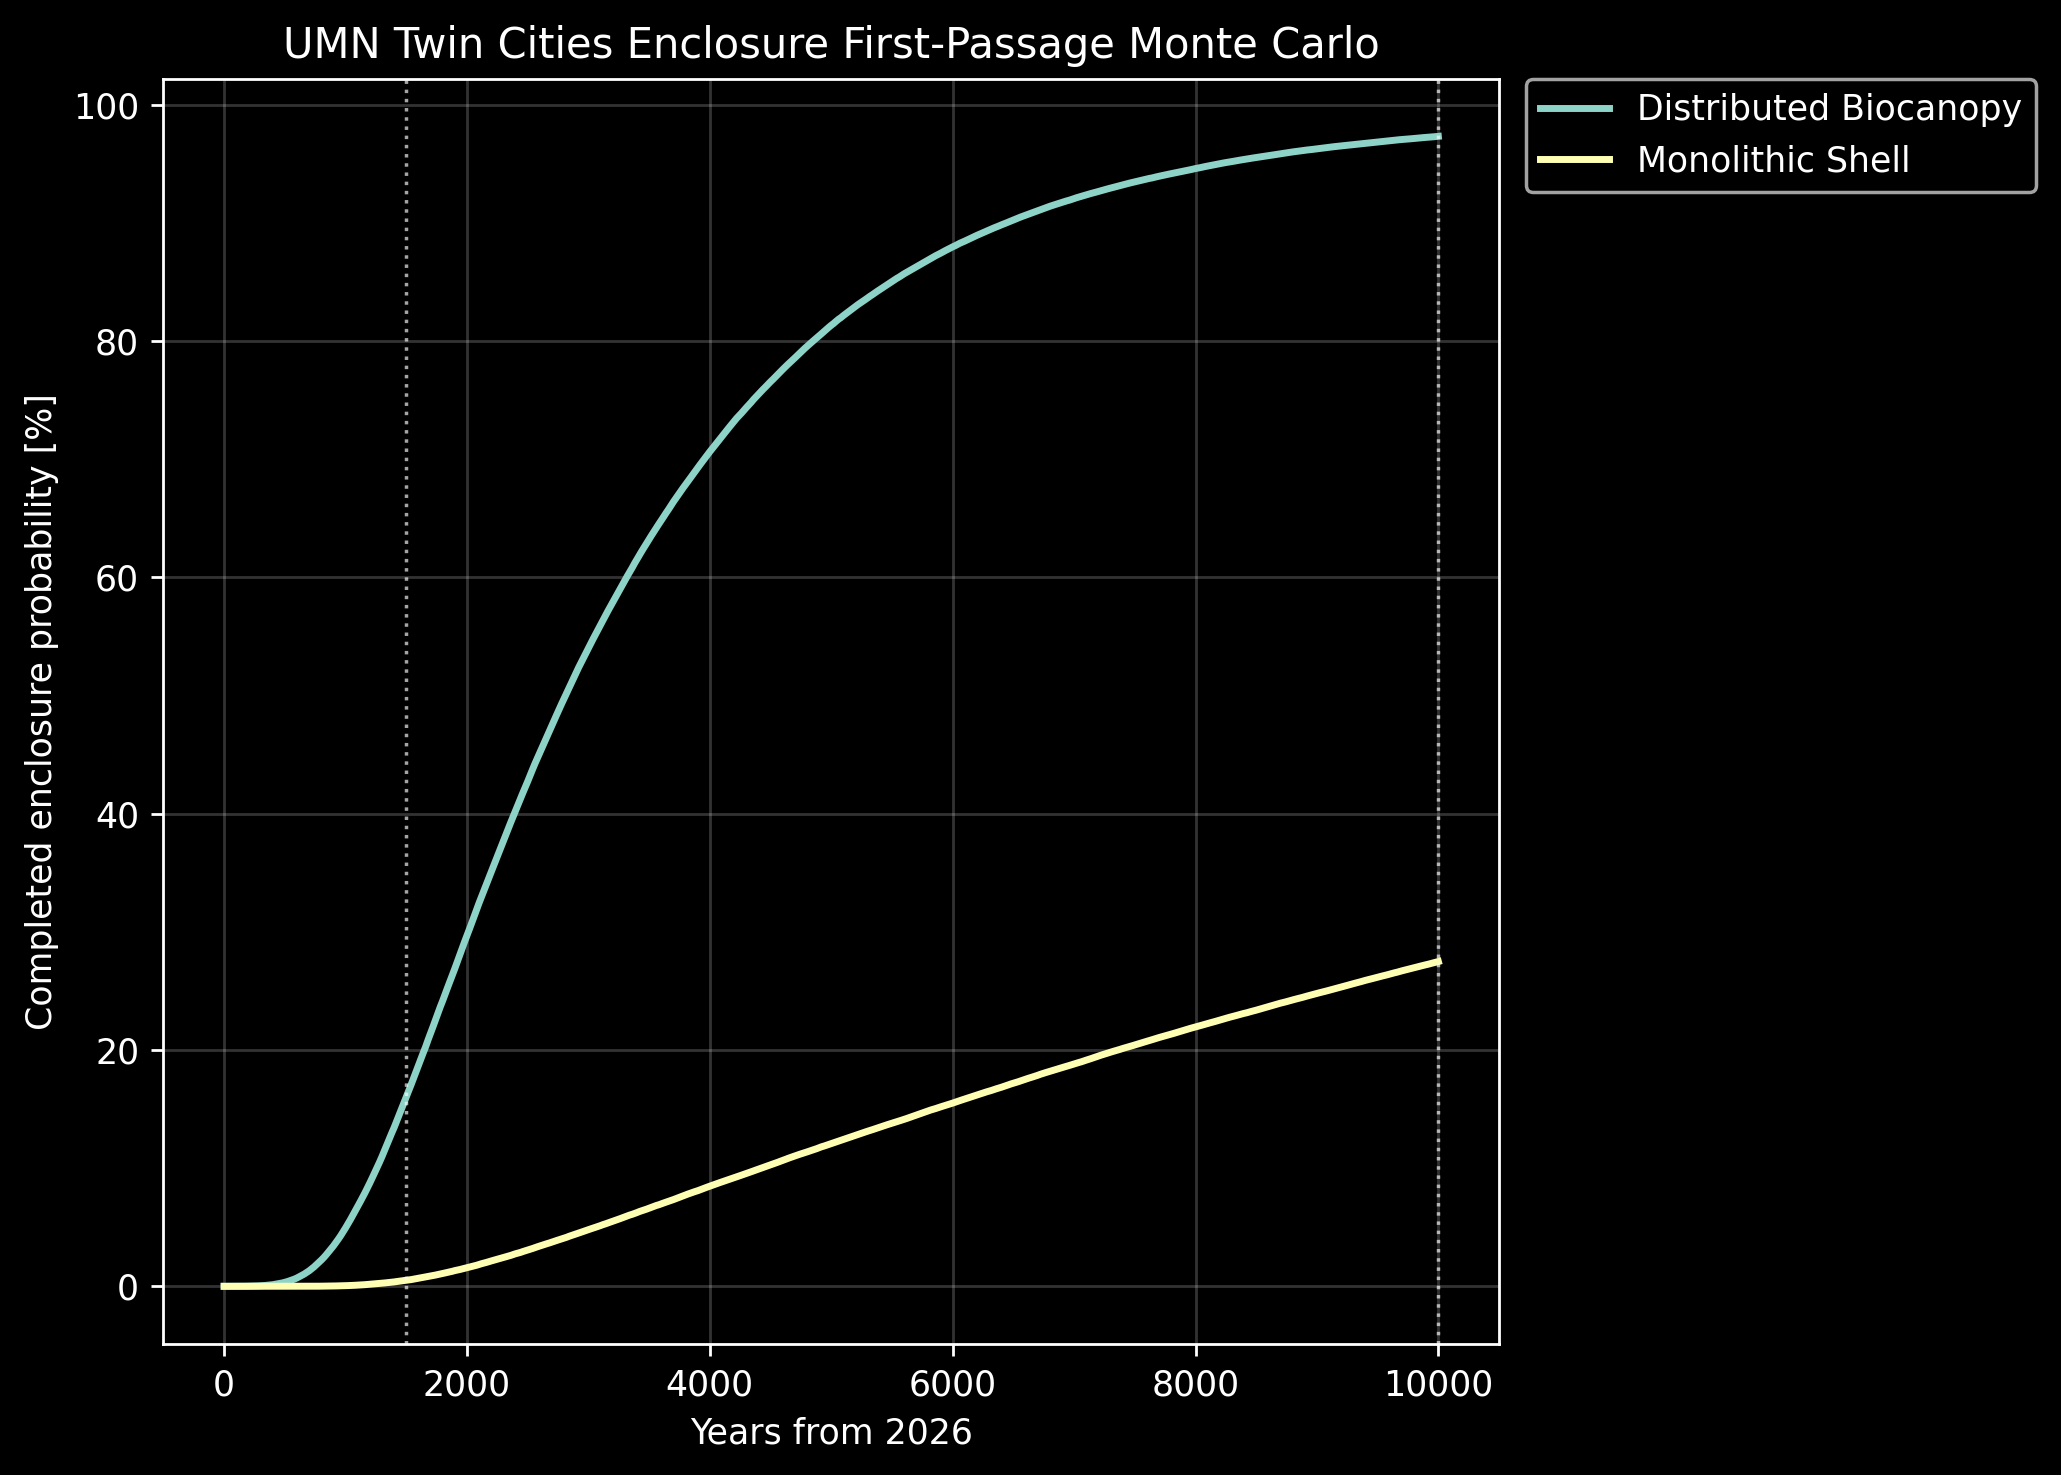

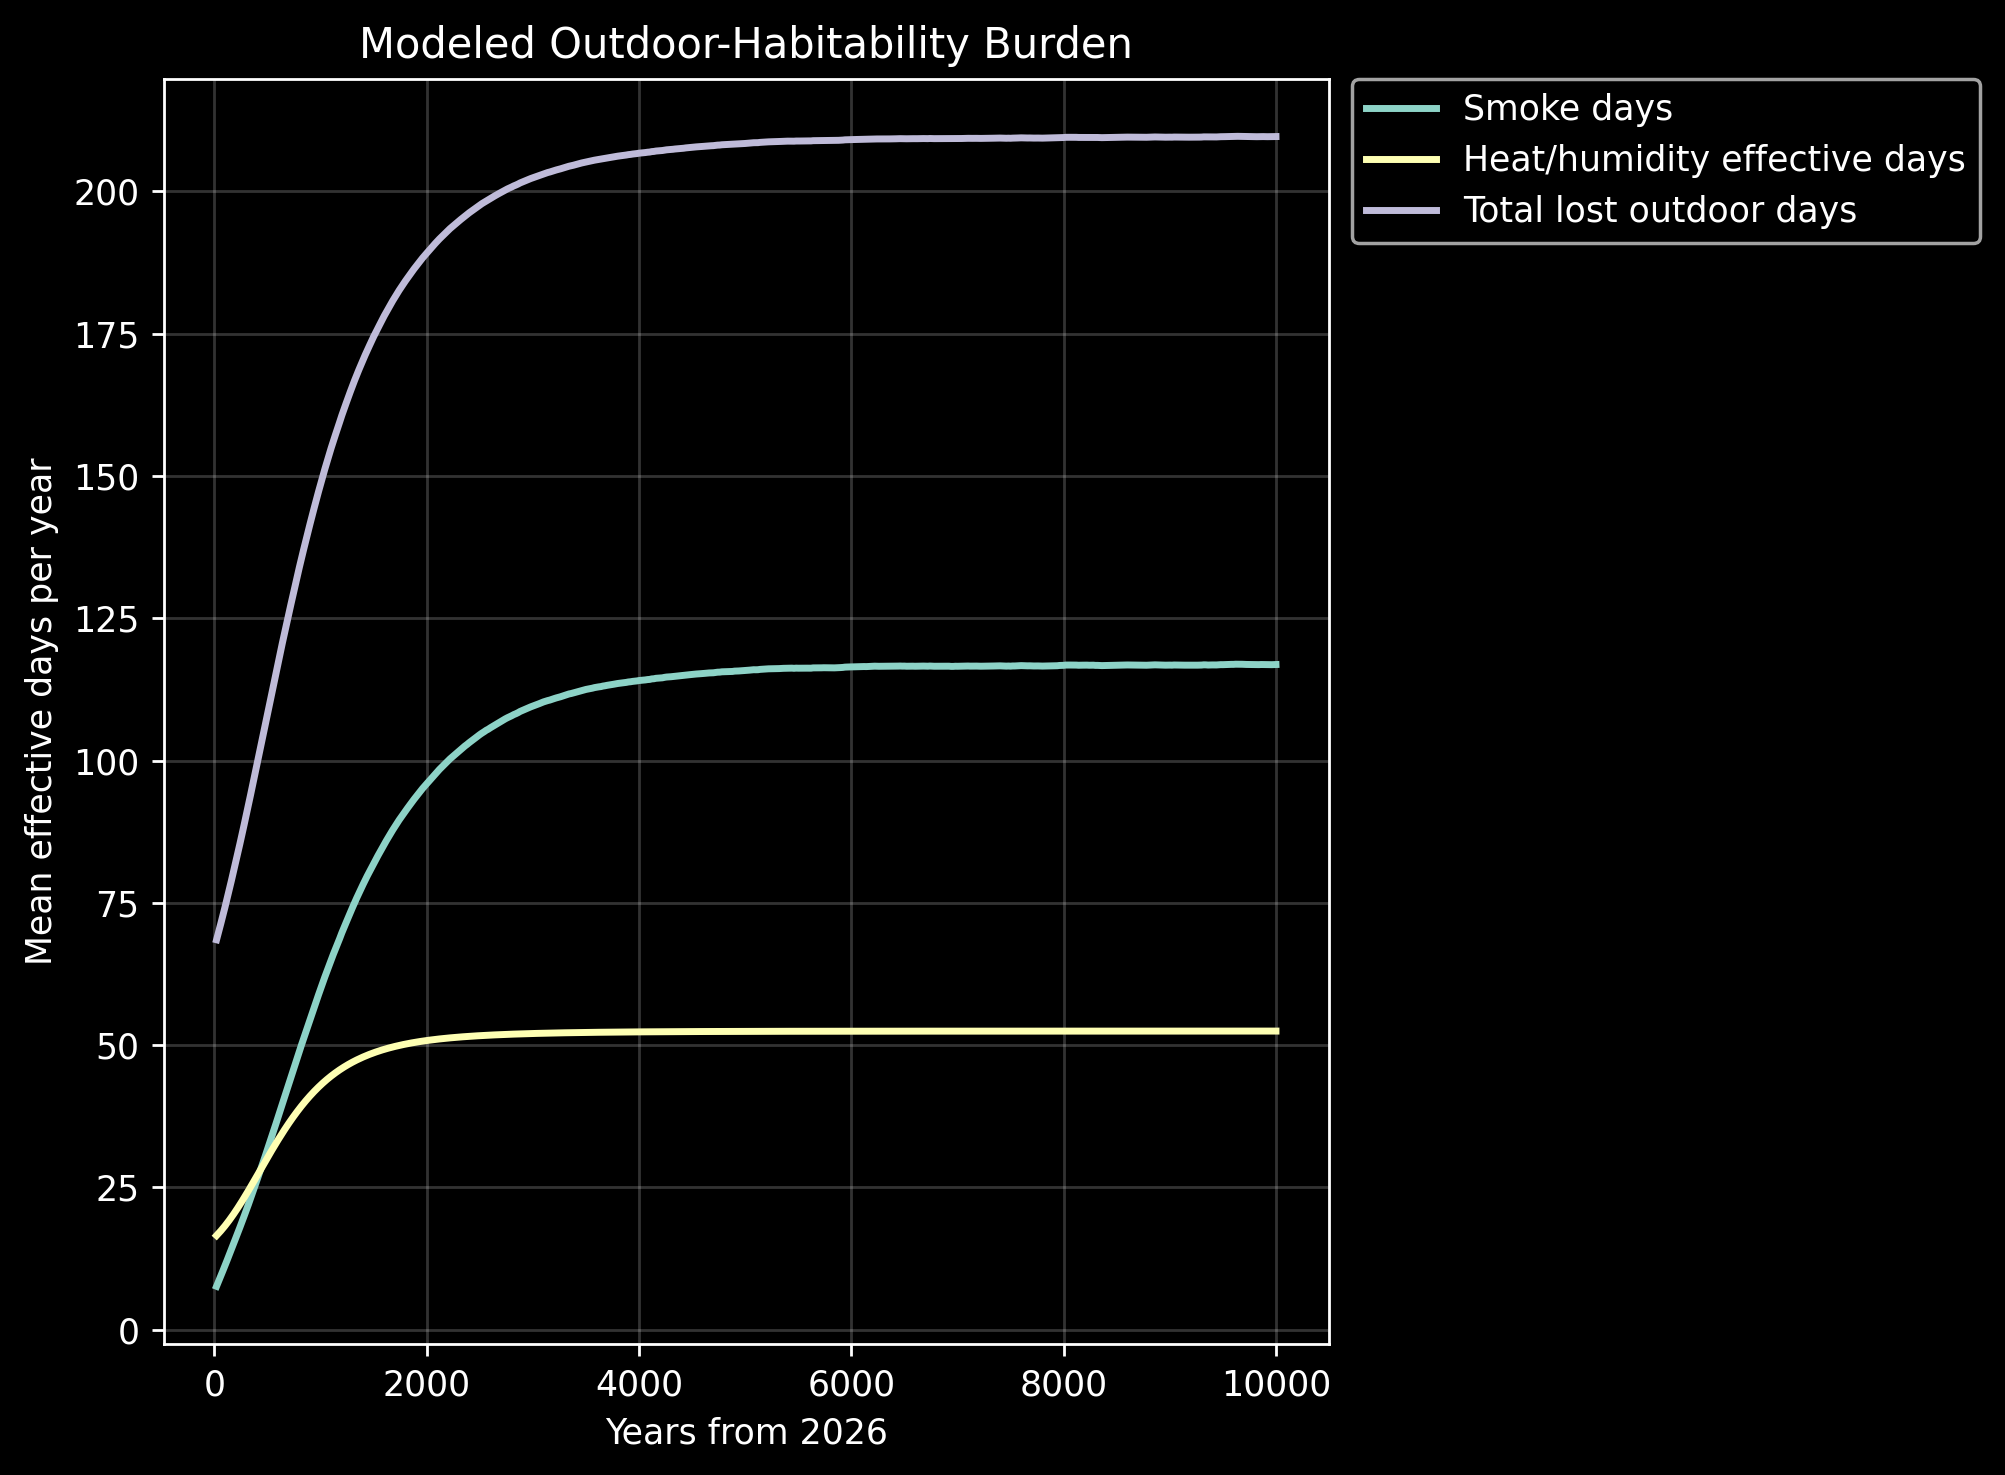

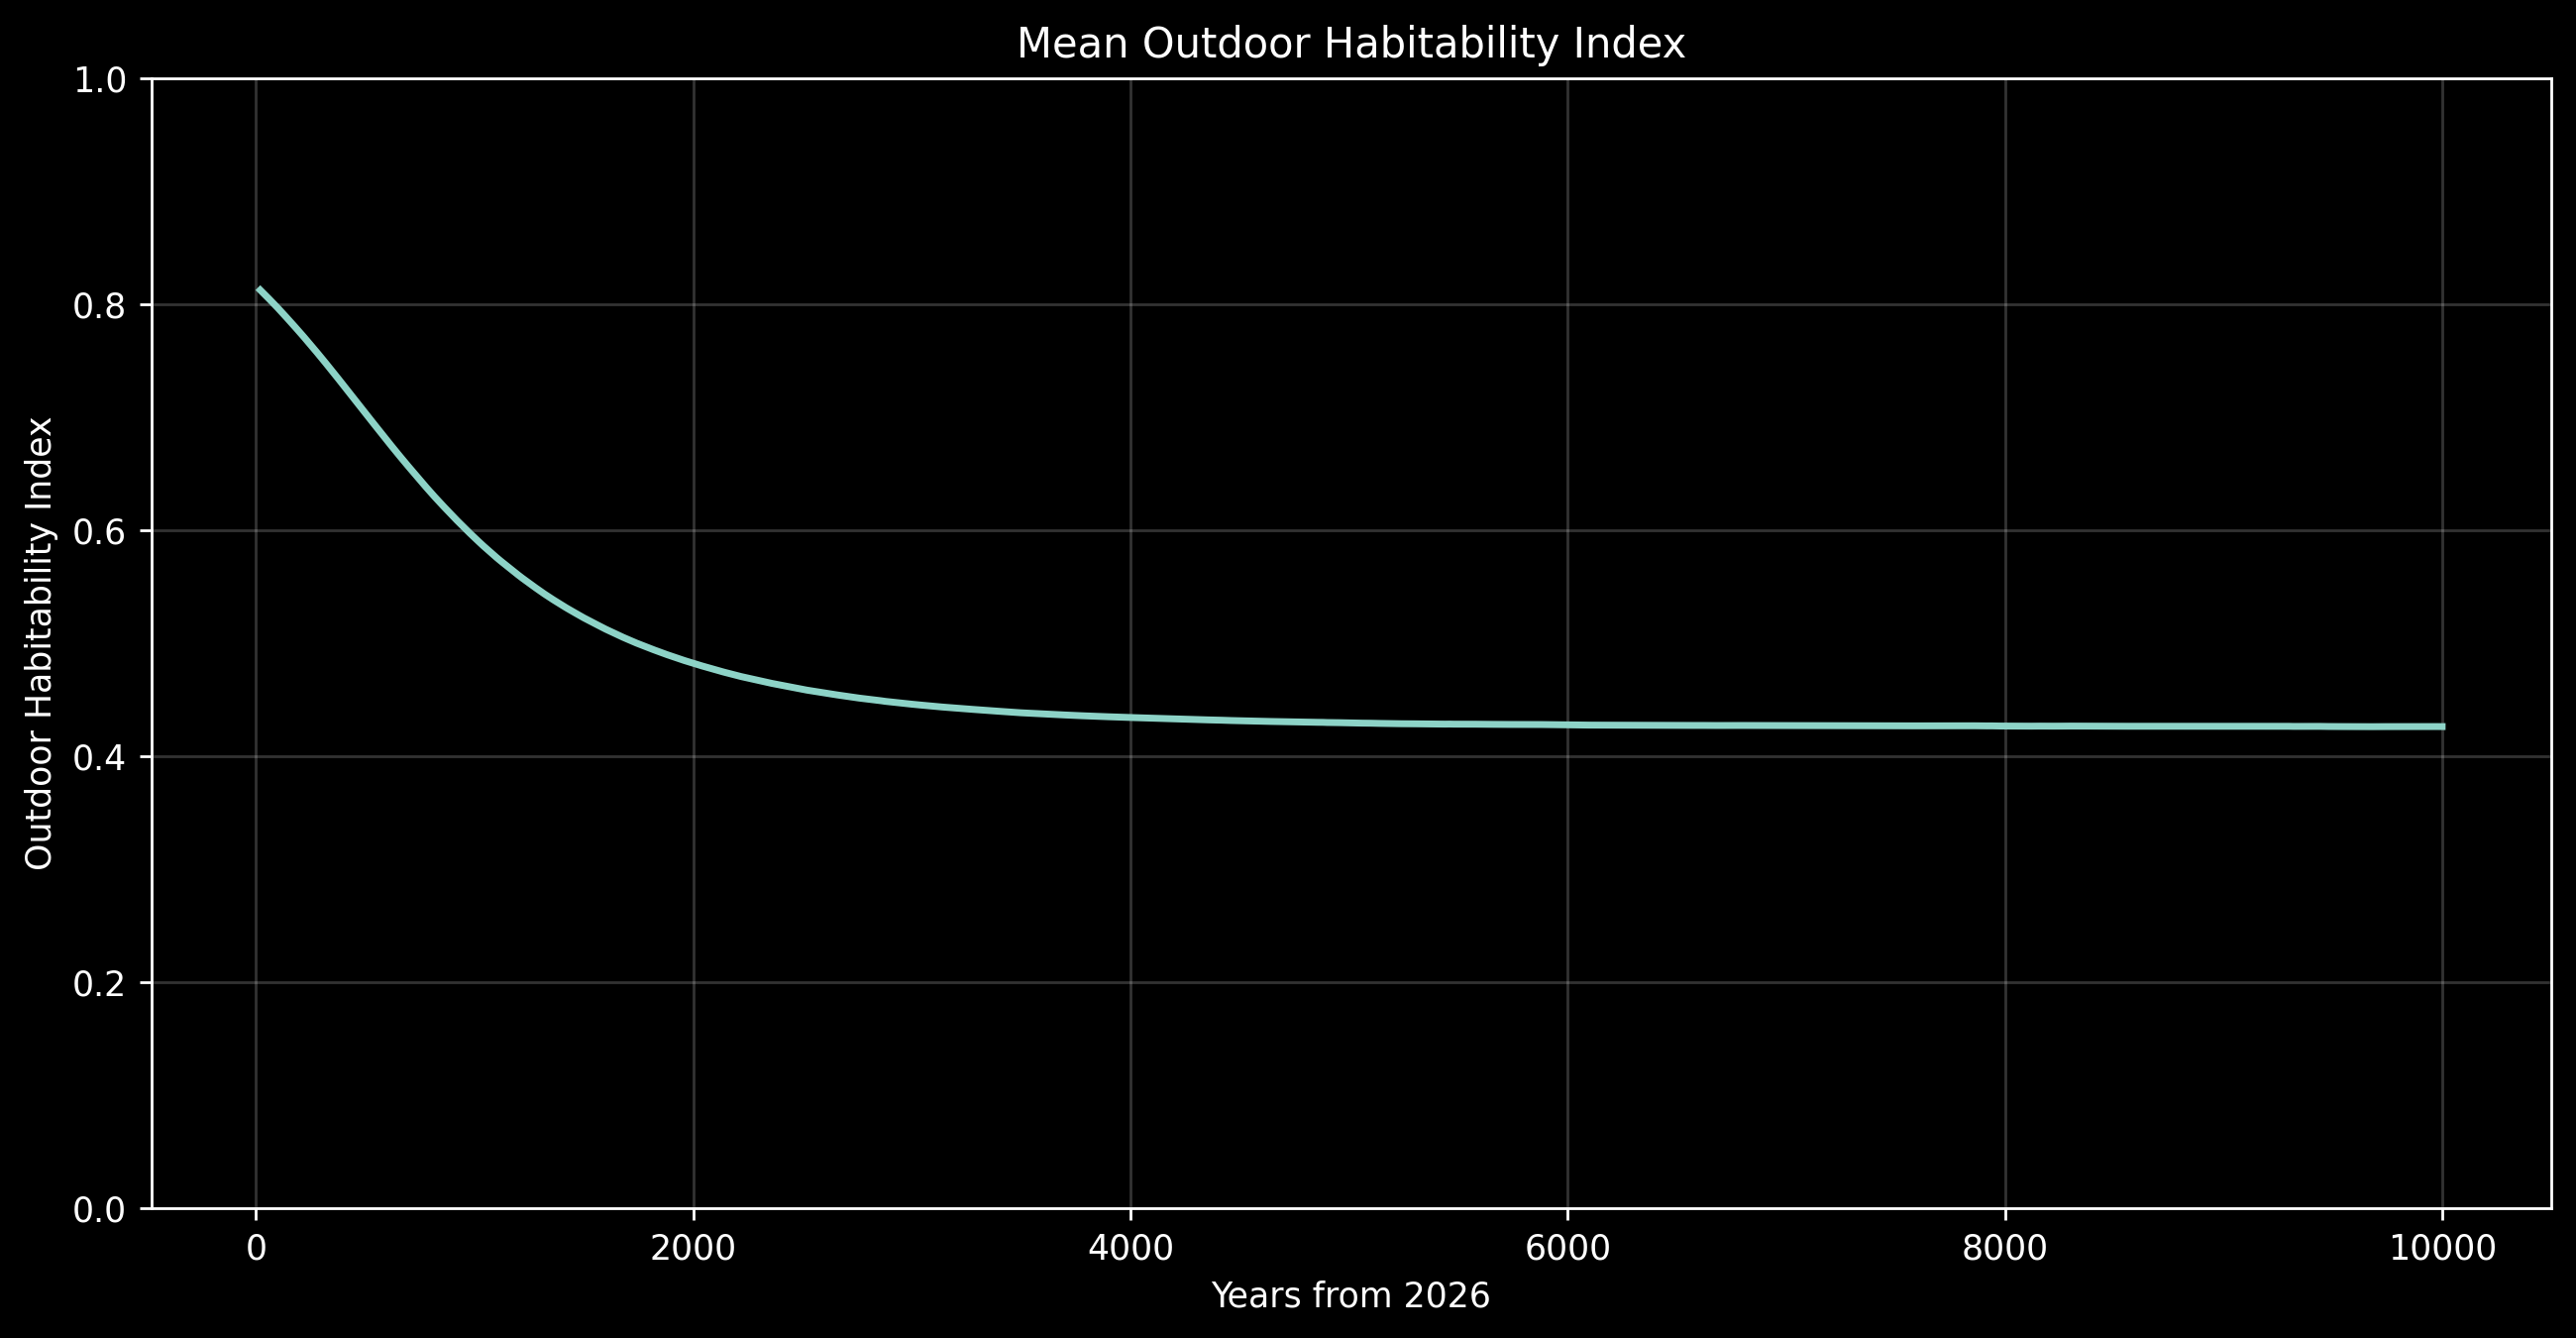


Sensitivity scenarios
                    scenario   p_1500  p_10000  uplift_1500_pp  uplift_10000_pp
      Combined pro-enclosure 0.297217 0.997317       13.753333         2.470000
    Technology + energy +30% 0.231667 0.992733        7.198333         2.011667
             Technology +30% 0.203983 0.989017        4.430000         1.640000
           Clean energy +30% 0.184483 0.981833        2.480000         0.921667
Adaptation alternatives -30% 0.181817 0.981150        2.213333         0.853333
           Smoke + heat +30% 0.179933 0.981250        2.025000         0.863333
         Wildfire smoke +60% 0.178850 0.981467        1.916667         0.885000
         Wildfire smoke +30% 0.171167 0.978567        1.148333         0.595000
                   Heat +30% 0.169400 0.976933        0.971667         0.431667
        Grid resilience +20% 0.166867 0.976783        0.718333         0.416667
                    Baseline 0.159683 0.972617        0.000000         0.000000
        Yellowsto

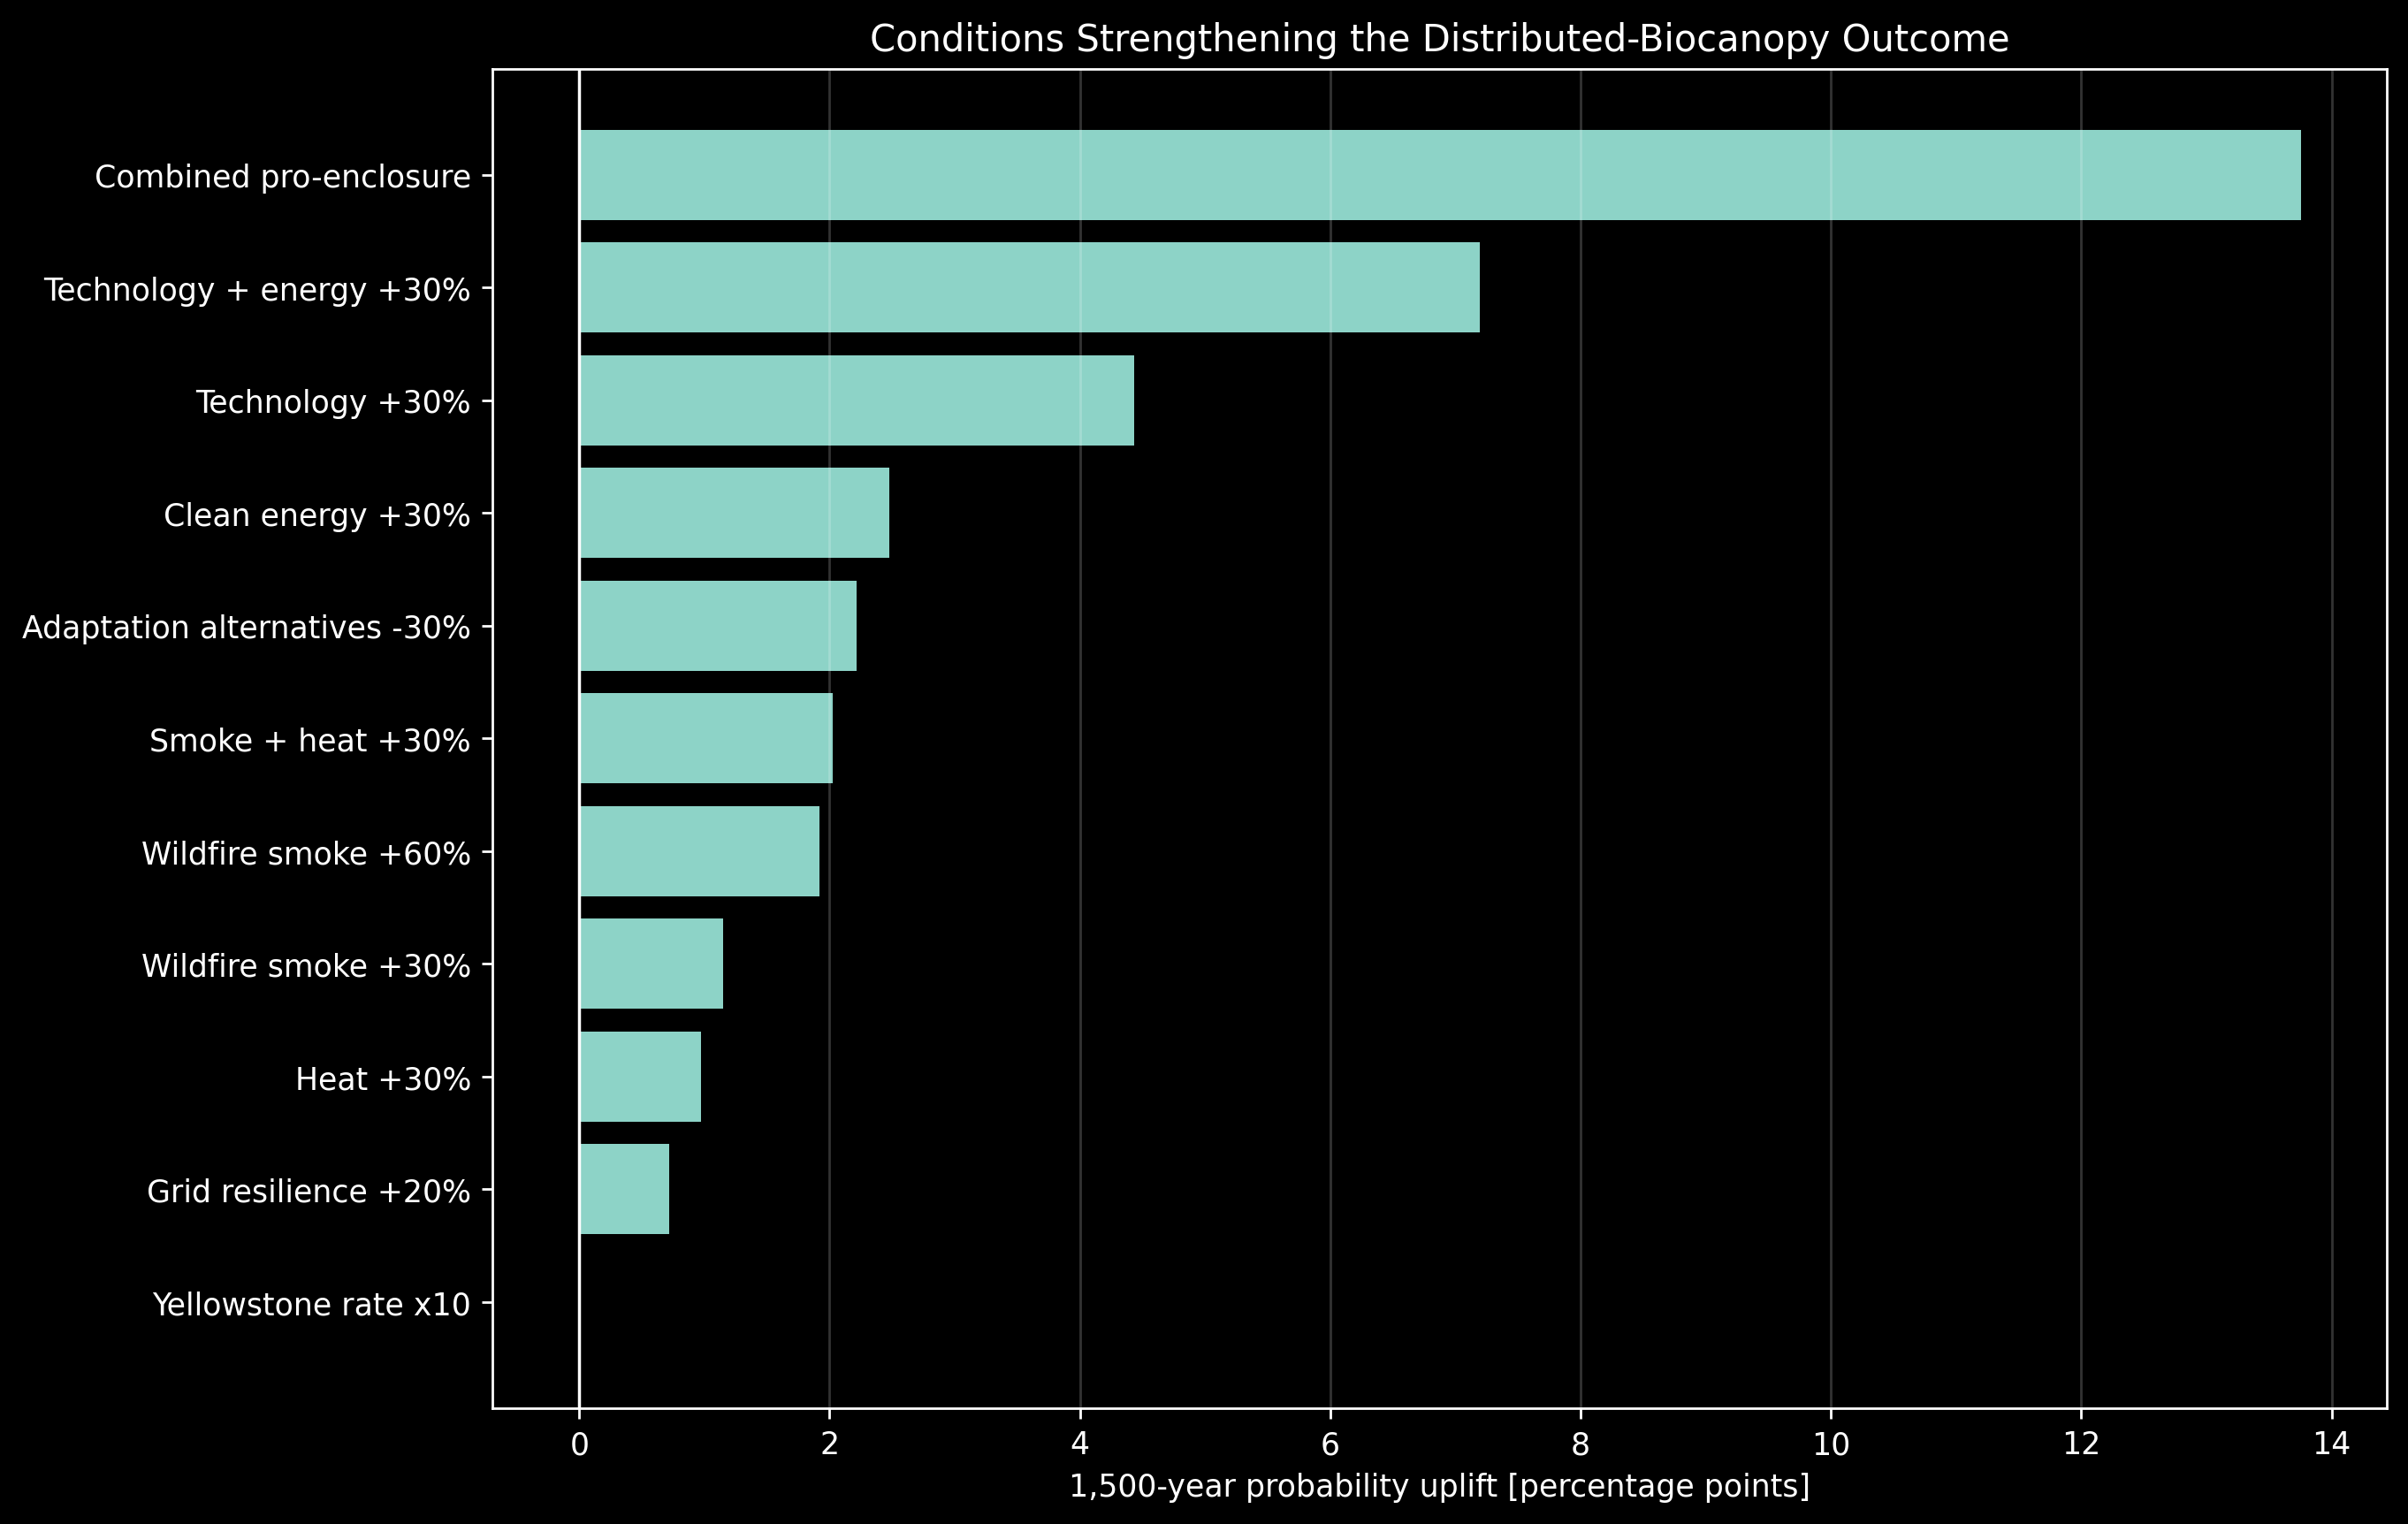

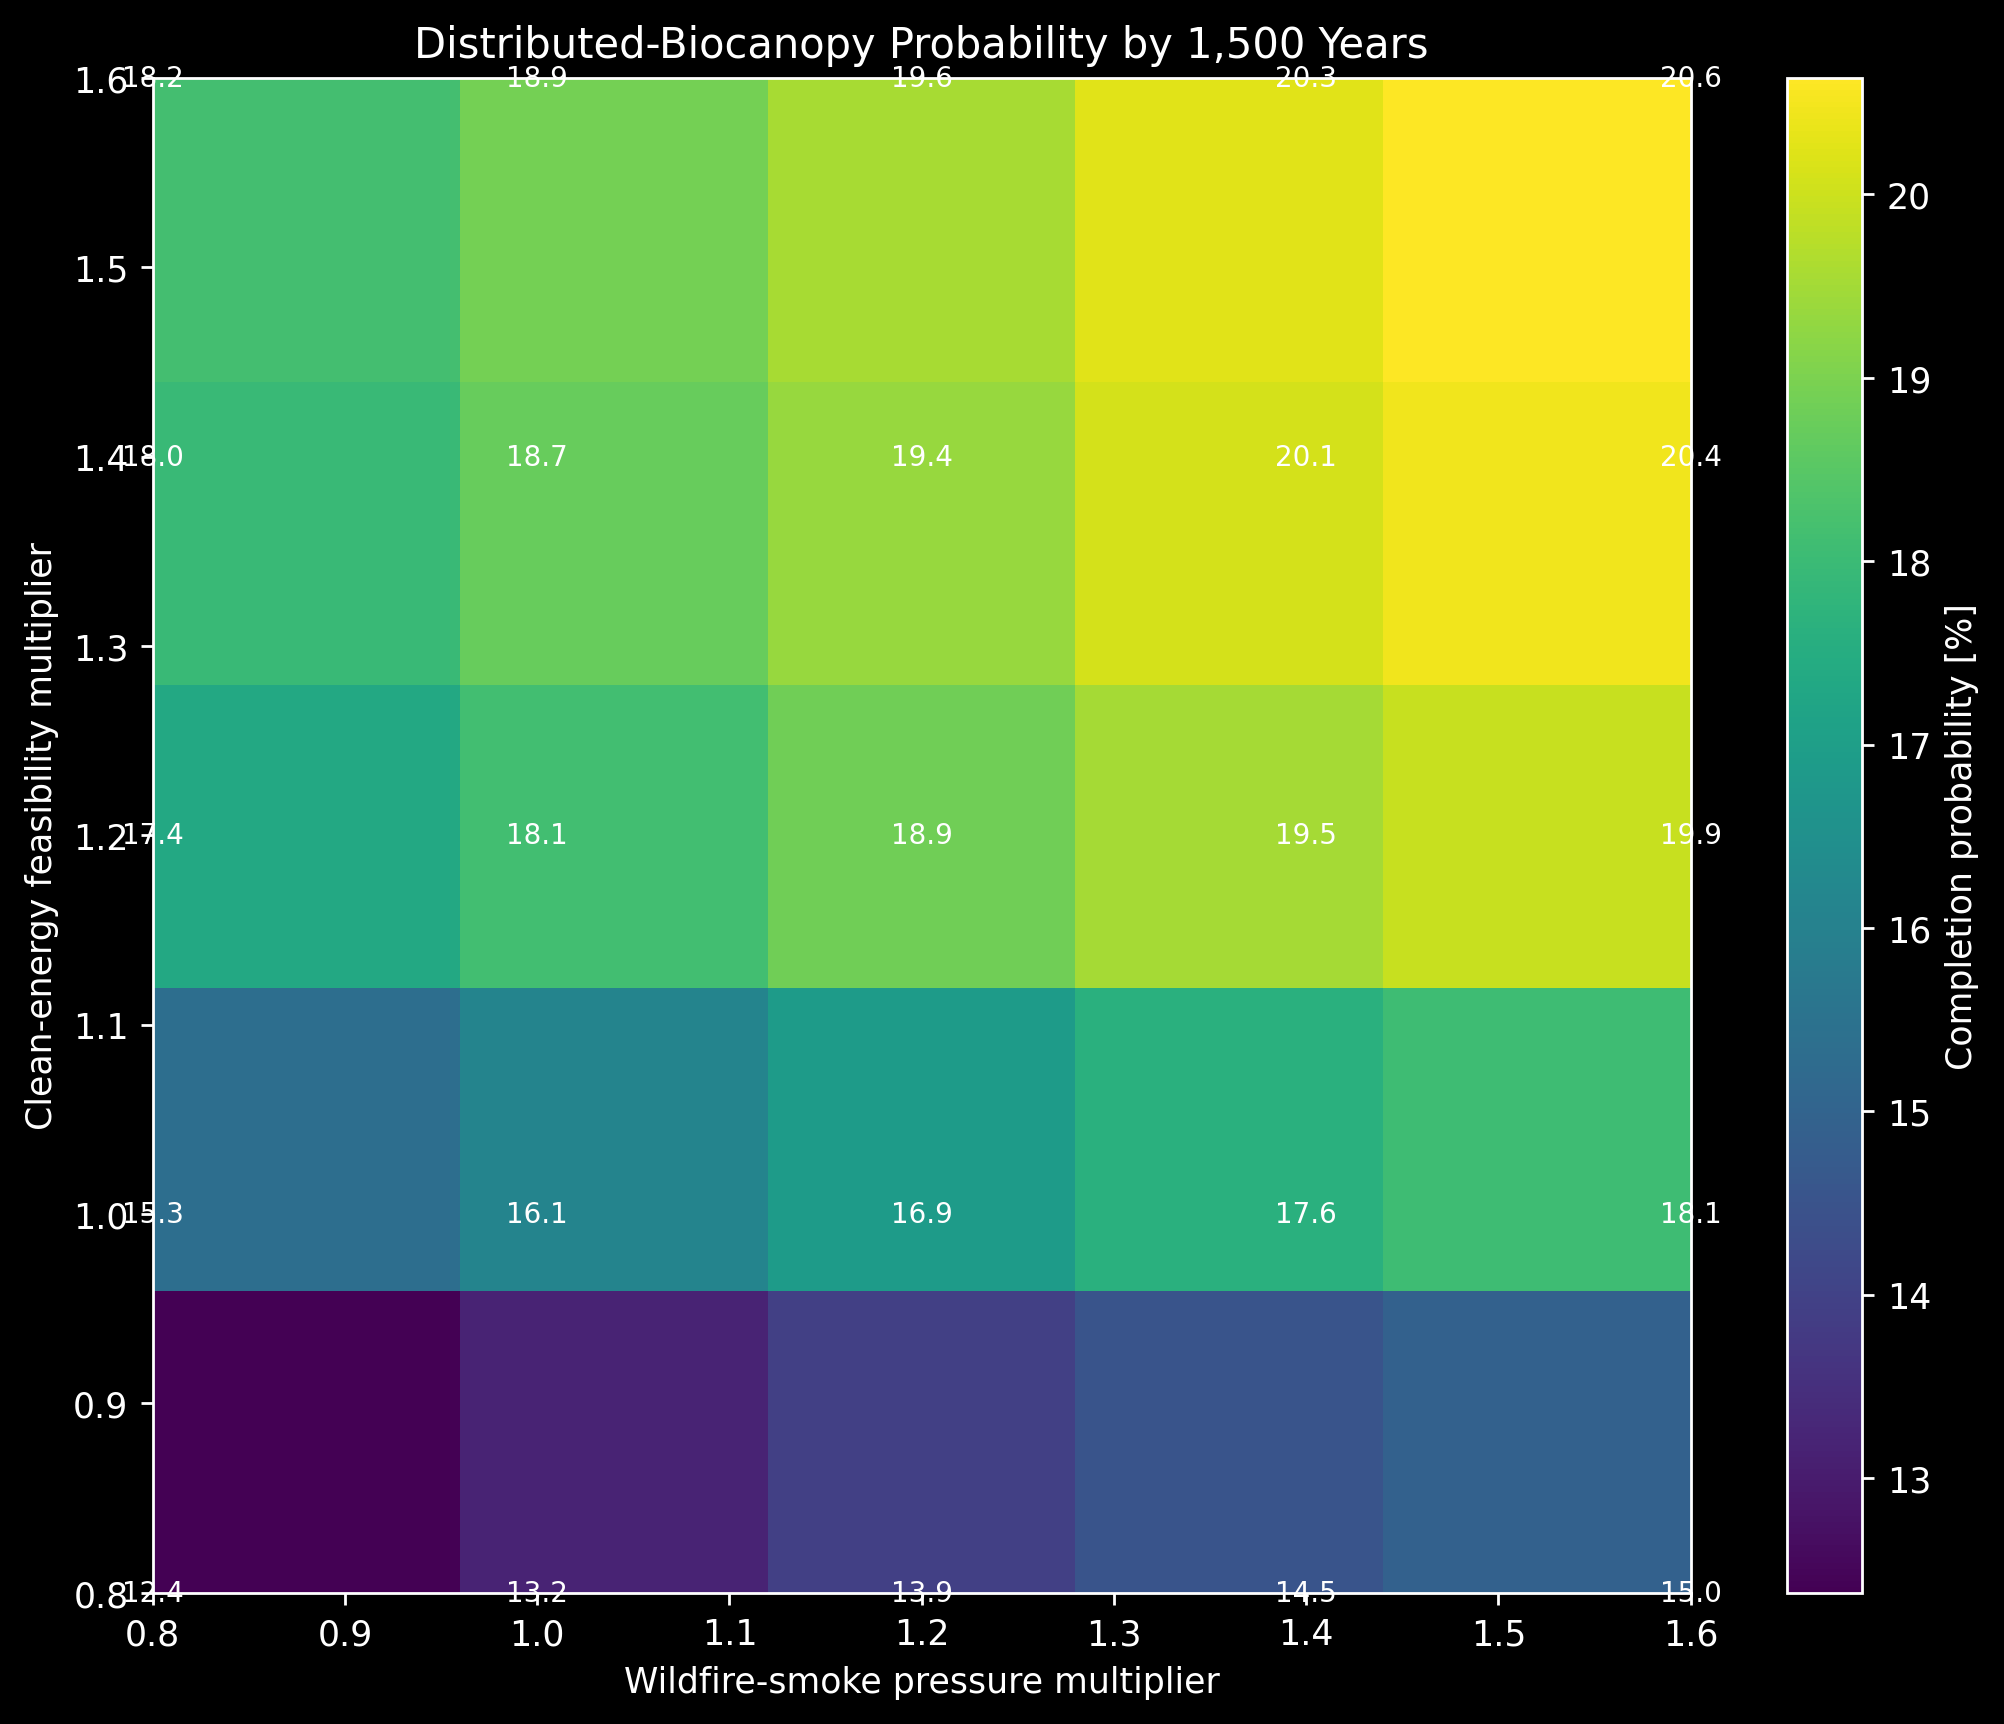


Saved outputs
umn_biodome_hazard_monte_carlo/architecture_cdf.png
umn_biodome_hazard_monte_carlo/environmental_burden.png
umn_biodome_hazard_monte_carlo/outdoor_habitability_index.png
umn_biodome_hazard_monte_carlo/sensitivity_uplift.png
umn_biodome_hazard_monte_carlo/smoke_energy_heatmap.png
umn_biodome_hazard_monte_carlo/architecture_summary.csv
umn_biodome_hazard_monte_carlo/sensitivity_scenarios.csv
umn_biodome_hazard_monte_carlo/environmental_diagnostics.csv
umn_biodome_hazard_monte_carlo/smoke_energy_heatmap.csv


In [6]:
"""GPU Monte Carlo model for a future UMN Twin Cities campus biodome.

The model treats campus-scale enclosure as a stochastic first-passage
infrastructure decision under uncertain technology, energy, environmental
pressure, campus density, policy, biosphere risk, and competing adaptation.
"""

import math
from dataclasses import dataclass
from pathlib import Path
from typing import Mapping

import cupy as cp
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# %% - Control knobs

RANDOM_SEED = 20260904
SMOKE_MARKOV_SEED = 731_941

N_TRIALS = 250_000
SENSITIVITY_TRIALS = 60_000
HEATMAP_TRIALS = 20_000

BATCH_SIZE = 20_000
DT_YEARS = 20
HORIZON_YEARS = 10_000
MILESTONES_YEARS = (1_500, 10_000)

PLOT_DPI = 250
DARK_PLOTS = True

OUTPUT_DIR = Path("umn_biodome_hazard_monte_carlo")
DOWNLOAD_OUTPUTS = False

RUN_SMOKE_ENERGY_HEATMAP = True
HEATMAP_HORIZON_YEARS = 1_500

# Institutional continuity. None treats the geographic campus site or its
# successor as the target. Set a finite half-life to penalize long horizons.
CONTINUITY_HALF_LIFE_YEARS: float | None = None

# First-passage adoption calibration.
BASELINE_SCORE_INTERCEPT = -2.75
TECH_ENERGY_INTERACTION = 1.20
POLICY_HABITABILITY_INTERACTION = 0.85
OUTDOOR_LOSS_WEIGHT = 4.00
LOST_OUTDOOR_DAYS_REFERENCE = 30.0
GATE_WIDTH = 0.07

# Lost-outdoor-day model.
DAYS_PER_YEAR = 365.25
COMPOUND_SMOKE_HEAT_DAYS = 60.0
MAX_TOTAL_LOST_OUTDOOR_DAYS = 340.0

# Regime-dependent smoke days. These are scenario priors, not historical
# measurements. The Markov state represents a multi-decadal smoke regime.
SMOKE_DAYS_MILD = 5.0
SMOKE_DAYS_SMOKY = 40.0
SMOKE_DAYS_PERSISTENT = 110.0
SMOKE_DAYS_CAP = 240.0

# Twenty-year transition probabilities, modified by the wildfire-smoke driver.
SMOKE_LOW_TO_SMOKY_BASE = 0.012
SMOKE_LOW_TO_PERSISTENT_BASE = 0.001
SMOKE_SMOKY_TO_LOW_BASE = 0.050
SMOKE_SMOKY_TO_PERSISTENT_BASE = 0.012
SMOKE_PERSISTENT_TO_LOW_BASE = 0.003
SMOKE_PERSISTENT_TO_SMOKY_BASE = 0.020
SMOKE_UPWARD_SENSITIVITY = 0.050
SMOKE_RECOVERY_SENSITIVITY = 0.035

# Rare Yellowstone caldera-forming-event prior.
# 1 / 730,000 yr is used as a deliberately crude scenario rate.
YELLOWSTONE_RATE_PER_YEAR = 1.0 / 730_000.0
YELLOWSTONE_RECOVERY_YEARS = 80.0
YELLOWSTONE_SEVERITY_LOG_SIGMA = 0.45
YELLOWSTONE_ADOPTION_WEIGHT = 1.20
YELLOWSTONE_ENERGY_DISRUPTION = 0.30
YELLOWSTONE_GRID_DISRUPTION = 0.45

# Construction-time uncertainty.
BUILD_LOG_SIGMA = 0.50


# %% - Model definitions

@dataclass(frozen=True)
class DriverSpec:
    """Describe one bounded long-run driver."""

    initial: float
    long_run_mean: float
    concentration: float
    midpoint_median_years: float
    midpoint_log_sigma: float
    transition_scale_years: float
    weight: float = 0.0


@dataclass(frozen=True)
class HazardSpec:
    """Map a normalized environmental driver to lost outdoor days."""

    driver_name: str
    maximum_days: float
    day_exponent: float
    exposure_weight: float


@dataclass(frozen=True)
class ArchitectureSpec:
    """Describe one enclosure architecture."""

    score_penalty: float
    max_annual_hazard: float
    technology_gate: float
    energy_gate: float
    grid_gate: float
    build_median_years: float
    ash_vulnerability: float
    ash_build_delay_years: float


@dataclass
class Cohort:
    """Store one common-random-number GPU Monte Carlo cohort."""

    levels: dict[str, cp.ndarray]
    midpoints: dict[str, cp.ndarray]
    thresholds: cp.ndarray
    build_z: cp.ndarray
    yellowstone_wait_years: cp.ndarray
    yellowstone_severity: cp.ndarray

    @property
    def size(self) -> int:
        """Return trial count."""
        return int(self.thresholds.size)


@dataclass
class SimulationResult:
    """Store completion times and optional environmental diagnostics."""

    completion_times: np.ndarray
    years: np.ndarray | None = None
    mean_lost_outdoor_days: np.ndarray | None = None
    mean_smoke_days: np.ndarray | None = None
    mean_heat_days: np.ndarray | None = None
    mean_outdoor_habitability: np.ndarray | None = None


DRIVERS = {
    # Environmental drivers.
    "wildfire_smoke_pressure": DriverSpec(
        initial=0.18,
        long_run_mean=0.58,
        concentration=8.0,
        midpoint_median_years=500.0,
        midpoint_log_sigma=0.90,
        transition_scale_years=250.0,
    ),
    "heat_humidity": DriverSpec(
        initial=0.18,
        long_run_mean=0.62,
        concentration=10.0,
        midpoint_median_years=450.0,
        midpoint_log_sigma=0.80,
        transition_scale_years=220.0,
    ),
    "heavy_precipitation": DriverSpec(
        initial=0.22,
        long_run_mean=0.55,
        concentration=10.0,
        midpoint_median_years=600.0,
        midpoint_log_sigma=0.90,
        transition_scale_years=280.0,
    ),
    "aeroallergen_burden": DriverSpec(
        initial=0.25,
        long_run_mean=0.55,
        concentration=10.0,
        midpoint_median_years=650.0,
        midpoint_log_sigma=0.90,
        transition_scale_years=300.0,
    ),
    "ozone_dust_burden": DriverSpec(
        initial=0.12,
        long_run_mean=0.42,
        concentration=9.0,
        midpoint_median_years=800.0,
        midpoint_log_sigma=1.00,
        transition_scale_years=350.0,
    ),
    "severe_weather": DriverSpec(
        initial=0.16,
        long_run_mean=0.45,
        concentration=9.0,
        midpoint_median_years=750.0,
        midpoint_log_sigma=0.95,
        transition_scale_years=330.0,
    ),
    "extreme_cold": DriverSpec(
        initial=0.45,
        long_run_mean=0.30,
        concentration=12.0,
        midpoint_median_years=550.0,
        midpoint_log_sigma=0.85,
        transition_scale_years=300.0,
    ),
    # Feasibility and institutional drivers.
    "enabling_technology": DriverSpec(
        initial=0.12,
        long_run_mean=0.78,
        concentration=10.0,
        midpoint_median_years=550.0,
        midpoint_log_sigma=0.80,
        transition_scale_years=240.0,
        weight=2.00,
    ),
    "clean_energy": DriverSpec(
        initial=0.22,
        long_run_mean=0.82,
        concentration=12.0,
        midpoint_median_years=350.0,
        midpoint_log_sigma=0.75,
        transition_scale_years=180.0,
        weight=1.60,
    ),
    "campus_density": DriverSpec(
        initial=0.35,
        long_run_mean=0.68,
        concentration=12.0,
        midpoint_median_years=1_100.0,
        midpoint_log_sigma=0.85,
        transition_scale_years=400.0,
        weight=0.75,
    ),
    "policy_support": DriverSpec(
        initial=0.18,
        long_run_mean=0.55,
        concentration=10.0,
        midpoint_median_years=700.0,
        midpoint_log_sigma=1.00,
        transition_scale_years=300.0,
        weight=0.75,
    ),
    "adaptation_alternatives": DriverSpec(
        initial=0.45,
        long_run_mean=0.80,
        concentration=12.0,
        midpoint_median_years=300.0,
        midpoint_log_sigma=0.70,
        transition_scale_years=200.0,
        weight=-1.40,
    ),
    "grid_resilience": DriverSpec(
        initial=0.50,
        long_run_mean=0.82,
        concentration=12.0,
        midpoint_median_years=350.0,
        midpoint_log_sigma=0.75,
        transition_scale_years=220.0,
        weight=0.55,
    ),
}

HAZARD_SPECS = {
    "heat_humidity": HazardSpec(
        driver_name="heat_humidity",
        maximum_days=105.0,
        day_exponent=1.25,
        exposure_weight=0.90,
    ),
    "heavy_precipitation": HazardSpec(
        driver_name="heavy_precipitation",
        maximum_days=75.0,
        day_exponent=1.10,
        exposure_weight=0.55,
    ),
    "aeroallergen_burden": HazardSpec(
        driver_name="aeroallergen_burden",
        maximum_days=95.0,
        day_exponent=1.00,
        exposure_weight=0.45,
    ),
    "ozone_dust_burden": HazardSpec(
        driver_name="ozone_dust_burden",
        maximum_days=60.0,
        day_exponent=1.15,
        exposure_weight=0.65,
    ),
    "severe_weather": HazardSpec(
        driver_name="severe_weather",
        maximum_days=42.0,
        day_exponent=1.20,
        exposure_weight=0.85,
    ),
    "extreme_cold": HazardSpec(
        driver_name="extreme_cold",
        maximum_days=55.0,
        day_exponent=1.10,
        exposure_weight=0.75,
    ),
}

ARCHITECTURES = {
    "distributed_biocanopy": ArchitectureSpec(
        score_penalty=0.00,
        max_annual_hazard=8.0e-4,
        technology_gate=0.45,
        energy_gate=0.35,
        grid_gate=0.45,
        build_median_years=75.0,
        ash_vulnerability=0.25,
        ash_build_delay_years=20.0,
    ),
    "monolithic_shell": ArchitectureSpec(
        score_penalty=2.00,
        max_annual_hazard=3.0e-4,
        technology_gate=0.72,
        energy_gate=0.55,
        grid_gate=0.70,
        build_median_years=180.0,
        ash_vulnerability=1.80,
        ash_build_delay_years=120.0,
    ),
}

SENSITIVITY_SCENARIOS = {
    "Baseline": {},
    "Wildfire smoke +30%": {
        "wildfire_smoke_pressure": 1.30,
    },
    "Wildfire smoke +60%": {
        "wildfire_smoke_pressure": 1.60,
    },
    "Heat +30%": {
        "heat_humidity": 1.30,
    },
    "Smoke + heat +30%": {
        "wildfire_smoke_pressure": 1.30,
        "heat_humidity": 1.30,
    },
    "Technology +30%": {
        "enabling_technology": 1.30,
    },
    "Clean energy +30%": {
        "clean_energy": 1.30,
    },
    "Grid resilience +20%": {
        "grid_resilience": 1.20,
    },
    "Adaptation alternatives -30%": {
        "adaptation_alternatives": 0.70,
    },
    "Yellowstone rate x10": {
        "yellowstone_rate": 10.0,
    },
    "Technology + energy +30%": {
        "enabling_technology": 1.30,
        "clean_energy": 1.30,
    },
    "Combined pro-enclosure": {
        "wildfire_smoke_pressure": 1.50,
        "heat_humidity": 1.35,
        "heavy_precipitation": 1.25,
        "aeroallergen_burden": 1.20,
        "ozone_dust_burden": 1.20,
        "severe_weather": 1.20,
        "enabling_technology": 1.30,
        "clean_energy": 1.30,
        "campus_density": 1.20,
        "policy_support": 1.30,
        "grid_resilience": 1.20,
        "adaptation_alternatives": 0.70,
    },
}


# %% - GPU helpers

def require_cuda_gpu() -> None:
    """Verify CUDA availability and print accelerator information."""
    device_count = cp.cuda.runtime.getDeviceCount()
    if device_count < 1:
        raise RuntimeError("A CUDA GPU is required.")

    props = cp.cuda.runtime.getDeviceProperties(0)
    device_name = props["name"]
    if isinstance(device_name, bytes):
        device_name = device_name.decode("utf-8")

    free_bytes, total_bytes = cp.cuda.runtime.memGetInfo()

    print(f"CUDA device              : {device_name}")
    print(
        "GPU memory free / total : "
        f"{free_bytes / 2**30:.2f} / {total_bytes / 2**30:.2f} GiB"
    )
    print(f"CuPy version             : {cp.__version__}")


def validate_random_backend() -> None:
    """Exercise every CuPy random primitive required by the simulation."""
    try:
        rng = cp.random.RandomState(RANDOM_SEED)

        beta_sample = rng.beta(
            2.0,
            3.0,
            size=16,
        ).astype(cp.float32)
        normal_sample = rng.standard_normal(
            size=16,
        ).astype(cp.float32)
        exponential_sample = rng.exponential(
            scale=2.0,
            size=16,
        ).astype(cp.float32)
        uniform_sample = rng.random_sample(
            size=16,
        ).astype(cp.float32)

        test_values = cp.concatenate(
            (
                beta_sample,
                normal_sample,
                exponential_sample,
                uniform_sample,
            )
        )

        if not bool(cp.all(cp.isfinite(test_values)).item()):
            raise RuntimeError(
                "CuPy random preflight produced non-finite values."
            )

        cp.cuda.runtime.deviceSynchronize()
    except Exception as exc:
        raise RuntimeError(
            "CuPy RandomState preflight failed. Reinstall a CUDA-12 CuPy "
            "wheel before running the Monte Carlo simulation."
        ) from exc

    print("CuPy RNG backend          : RandomState [PASS]")


def sigmoid(values: cp.ndarray) -> cp.ndarray:
    """Evaluate a numerically stable logistic function."""
    clipped = cp.clip(values, -30.0, 30.0)
    return 1.0 / (1.0 + cp.exp(-clipped))


def sample_cohort(n_trials: int, seed: int) -> Cohort:
    """Generate a GPU-resident common-random-number cohort."""
    rng = cp.random.RandomState(seed)

    levels = {}
    midpoints = {}

    for name, spec in DRIVERS.items():
        alpha = spec.long_run_mean * spec.concentration
        beta = (1.0 - spec.long_run_mean) * spec.concentration

        levels[name] = rng.beta(
            alpha,
            beta,
            size=n_trials,
        ).astype(cp.float32)

        midpoint_z = rng.standard_normal(
            size=n_trials,
        ).astype(cp.float32)

        midpoints[name] = cp.exp(
            cp.float32(math.log(spec.midpoint_median_years))
            + cp.float32(spec.midpoint_log_sigma) * midpoint_z
        ).astype(cp.float32)

    thresholds = rng.exponential(
        scale=1.0,
        size=n_trials,
    ).astype(cp.float32)

    build_z = rng.standard_normal(
        size=n_trials,
    ).astype(cp.float32)

    yellowstone_wait_years = rng.exponential(
        scale=1.0 / YELLOWSTONE_RATE_PER_YEAR,
        size=n_trials,
    ).astype(cp.float32)

    severity_z = rng.standard_normal(
        size=n_trials,
    ).astype(cp.float32)

    yellowstone_severity = cp.exp(
        cp.float32(YELLOWSTONE_SEVERITY_LOG_SIGMA) * severity_z
        - cp.float32(0.5 * YELLOWSTONE_SEVERITY_LOG_SIGMA**2)
    ).astype(cp.float32)

    return Cohort(
        levels=levels,
        midpoints=midpoints,
        thresholds=thresholds,
        build_z=build_z,
        yellowstone_wait_years=yellowstone_wait_years,
        yellowstone_severity=yellowstone_severity,
    )


def driver_curve(
    times: cp.ndarray,
    levels: cp.ndarray,
    midpoints: cp.ndarray,
    spec: DriverSpec,
    multiplier: float,
) -> cp.ndarray:
    """Generate one bounded long-run trajectory."""
    asymptote = cp.clip(
        levels * cp.float32(multiplier),
        0.01,
        0.99,
    )

    scaled_time = (
        times - midpoints[:, None]
    ) / cp.float32(spec.transition_scale_years)

    return (
        cp.float32(spec.initial)
        + (
            asymptote[:, None]
            - cp.float32(spec.initial)
        )
        * sigmoid(scaled_time)
    )


def continuity_factor(times: cp.ndarray) -> cp.ndarray | cp.float32:
    """Return optional institutional-site persistence."""
    if CONTINUITY_HALF_LIFE_YEARS is None:
        return cp.float32(1.0)

    decay = math.log(2.0) / CONTINUITY_HALF_LIFE_YEARS
    return cp.exp(-cp.float32(decay) * times)


def generate_smoke_days(
    smoke_pressure: cp.ndarray,
    rng: cp.random.RandomState,
) -> cp.ndarray:
    """Simulate multi-decadal Canadian-wildfire-smoke regimes on the GPU."""
    n_trials, n_steps = smoke_pressure.shape

    state = cp.zeros(n_trials, dtype=cp.int8)
    initial_u = rng.random_sample(n_trials).astype(cp.float32)

    state = cp.where(
        initial_u < 0.01,
        cp.int8(2),
        cp.where(
            initial_u < 0.10,
            cp.int8(1),
            cp.int8(0),
        ),
    ).astype(cp.int8)

    smoke_days = cp.empty_like(smoke_pressure, dtype=cp.float32)

    for step in range(n_steps):
        pressure = smoke_pressure[:, step]

        base_days = cp.where(
            state == 0,
            cp.float32(SMOKE_DAYS_MILD),
            cp.where(
                state == 1,
                cp.float32(SMOKE_DAYS_SMOKY),
                cp.float32(SMOKE_DAYS_PERSISTENT),
            ),
        )

        smoke_days[:, step] = cp.minimum(
            cp.float32(SMOKE_DAYS_CAP),
            base_days * (
                cp.float32(0.55)
                + cp.float32(1.15) * pressure
            ),
        )

        transition_u = rng.random_sample(n_trials).astype(cp.float32)

        low_to_persistent = (
            cp.float32(SMOKE_LOW_TO_PERSISTENT_BASE)
            + cp.float32(0.15 * SMOKE_UPWARD_SENSITIVITY) * pressure
        )

        low_to_smoky = (
            cp.float32(SMOKE_LOW_TO_SMOKY_BASE)
            + cp.float32(SMOKE_UPWARD_SENSITIVITY) * pressure
        )

        smoky_to_low = cp.maximum(
            cp.float32(0.005),
            cp.float32(SMOKE_SMOKY_TO_LOW_BASE)
            - cp.float32(SMOKE_RECOVERY_SENSITIVITY) * pressure,
        )

        smoky_to_persistent = (
            cp.float32(SMOKE_SMOKY_TO_PERSISTENT_BASE)
            + cp.float32(SMOKE_UPWARD_SENSITIVITY) * pressure
        )

        persistent_to_low = cp.maximum(
            cp.float32(0.0005),
            cp.float32(SMOKE_PERSISTENT_TO_LOW_BASE)
            * (cp.float32(1.0) - pressure),
        )

        persistent_to_smoky = cp.maximum(
            cp.float32(0.002),
            cp.float32(SMOKE_PERSISTENT_TO_SMOKY_BASE)
            - cp.float32(SMOKE_RECOVERY_SENSITIVITY) * pressure,
        )

        next_state = state.copy()

        low_mask = state == 0
        next_state = cp.where(
            low_mask & (transition_u < low_to_persistent),
            cp.int8(2),
            next_state,
        )
        next_state = cp.where(
            low_mask
            & (transition_u >= low_to_persistent)
            & (
                transition_u
                < low_to_persistent + low_to_smoky
            ),
            cp.int8(1),
            next_state,
        )

        smoky_mask = state == 1
        next_state = cp.where(
            smoky_mask & (transition_u < smoky_to_low),
            cp.int8(0),
            next_state,
        )
        next_state = cp.where(
            smoky_mask
            & (transition_u >= smoky_to_low)
            & (
                transition_u
                < smoky_to_low + smoky_to_persistent
            ),
            cp.int8(2),
            next_state,
        )

        persistent_mask = state == 2
        next_state = cp.where(
            persistent_mask & (transition_u < persistent_to_low),
            cp.int8(0),
            next_state,
        )
        next_state = cp.where(
            persistent_mask
            & (transition_u >= persistent_to_low)
            & (
                transition_u
                < persistent_to_low + persistent_to_smoky
            ),
            cp.int8(1),
            next_state,
        )

        state = next_state

    return smoke_days


def yellowstone_shock_curve(
    times: cp.ndarray,
    event_time: cp.ndarray,
    severity: cp.ndarray,
) -> cp.ndarray:
    """Return post-eruption atmospheric and ash stress with exponential decay."""
    elapsed = times - event_time[:, None]
    occurred = elapsed >= 0.0

    recovery = cp.exp(
        -cp.maximum(elapsed, 0.0)
        / cp.float32(YELLOWSTONE_RECOVERY_YEARS)
    )

    return (
        occurred.astype(cp.float32)
        * severity[:, None]
        * recovery
    )


def hazard_days_from_driver(
    trajectory: cp.ndarray,
    spec: HazardSpec,
) -> cp.ndarray:
    """Convert normalized severity to effective annual exposure days."""
    raw_days = (
        cp.float32(spec.maximum_days)
        * cp.power(
            cp.clip(trajectory, 0.0, 1.0),
            cp.float32(spec.day_exponent),
        )
    )
    return cp.float32(spec.exposure_weight) * raw_days


def combine_lost_outdoor_days(
    smoke_days: cp.ndarray,
    hazard_day_arrays: list[cp.ndarray],
    heat_days: cp.ndarray,
) -> cp.ndarray:
    """Combine overlapping hazards using a union-of-days approximation."""
    outdoor_fraction = cp.ones_like(smoke_days, dtype=cp.float32)

    all_day_arrays = [smoke_days] + hazard_day_arrays

    for day_array in all_day_arrays:
        outdoor_fraction *= (
            cp.float32(1.0)
            - cp.clip(
                day_array / cp.float32(DAYS_PER_YEAR),
                0.0,
                0.98,
            )
        )

    union_days = cp.float32(DAYS_PER_YEAR) * (
        cp.float32(1.0) - outdoor_fraction
    )

    smoke_fraction = cp.clip(
        smoke_days / cp.float32(DAYS_PER_YEAR),
        0.0,
        1.0,
    )

    heat_fraction = cp.clip(
        heat_days / cp.float32(DAYS_PER_YEAR),
        0.0,
        1.0,
    )

    compound_days = (
        cp.float32(COMPOUND_SMOKE_HEAT_DAYS)
        * cp.sqrt(smoke_fraction * heat_fraction)
    )

    return cp.minimum(
        cp.float32(MAX_TOTAL_LOST_OUTDOOR_DAYS),
        union_days + compound_days,
    )


# %% - GPU first-passage Monte Carlo

def simulate_completion_times(
    cohort: Cohort,
    architecture_name: str,
    multipliers: Mapping[str, float] | None = None,
    horizon_years: int = HORIZON_YEARS,
    collect_diagnostics: bool = False,
) -> SimulationResult:
    """Simulate completed campus-enclosure times.

    Args:
        cohort: GPU Monte Carlo cohort.
        architecture_name: Architecture key.
        multipliers: Scenario multipliers. Driver names modify long-run levels.
            The special key ``yellowstone_rate`` scales the rare-event rate.
        horizon_years: Decision simulation horizon.
        collect_diagnostics: Whether to accumulate mean environmental traces.

    Returns:
        SimulationResult containing completion times and optional diagnostics.
    """
    architecture = ARCHITECTURES[architecture_name]
    scenario = {} if multipliers is None else dict(multipliers)

    time_vector = cp.arange(
        DT_YEARS,
        horizon_years + DT_YEARS,
        DT_YEARS,
        dtype=cp.float32,
    )
    times = time_vector[None, :]
    n_steps = int(time_vector.size)

    persistence = continuity_factor(times)

    completion_times = cp.full(
        cohort.size,
        cp.inf,
        dtype=cp.float32,
    )

    smoke_rng = cp.random.RandomState(SMOKE_MARKOV_SEED)

    if collect_diagnostics:
        lost_days_sum = cp.zeros(n_steps, dtype=cp.float64)
        smoke_days_sum = cp.zeros(n_steps, dtype=cp.float64)
        heat_days_sum = cp.zeros(n_steps, dtype=cp.float64)

    for start in range(0, cohort.size, BATCH_SIZE):
        stop = min(start + BATCH_SIZE, cohort.size)
        n_batch = stop - start

        score = cp.full(
            (n_batch, n_steps),
            cp.float32(
                BASELINE_SCORE_INTERCEPT
                - architecture.score_penalty
            ),
            dtype=cp.float32,
        )

        retained = {}
        hazard_day_arrays = []
        heat_days = None

        for name, spec in DRIVERS.items():
            trajectory = driver_curve(
                times=times,
                levels=cohort.levels[name][start:stop],
                midpoints=cohort.midpoints[name][start:stop],
                spec=spec,
                multiplier=scenario.get(name, 1.0),
            )

            if spec.weight != 0.0:
                score += cp.float32(spec.weight) * (
                    trajectory - cp.float32(0.5)
                )

            if name in {
                "enabling_technology",
                "clean_energy",
                "policy_support",
                "grid_resilience",
            }:
                retained[name] = trajectory

            if name in HAZARD_SPECS:
                hazard_spec = HAZARD_SPECS[name]
                effective_days = hazard_days_from_driver(
                    trajectory,
                    hazard_spec,
                )
                hazard_day_arrays.append(effective_days)

                if name == "heat_humidity":
                    heat_days = effective_days

            if name == "wildfire_smoke_pressure":
                retained[name] = trajectory

        if heat_days is None:
            raise RuntimeError("Heat-humidity hazard trajectory is missing.")

        smoke_days = generate_smoke_days(
            retained["wildfire_smoke_pressure"],
            smoke_rng,
        )

        lost_outdoor_days = combine_lost_outdoor_days(
            smoke_days=smoke_days,
            hazard_day_arrays=hazard_day_arrays,
            heat_days=heat_days,
        )

        outdoor_habitability = (
            cp.float32(1.0)
            - lost_outdoor_days / cp.float32(DAYS_PER_YEAR)
        )

        score += cp.float32(OUTDOOR_LOSS_WEIGHT) * (
            (
                lost_outdoor_days
                - cp.float32(LOST_OUTDOOR_DAYS_REFERENCE)
            )
            / cp.float32(DAYS_PER_YEAR)
        )

        technology = retained["enabling_technology"]
        energy = retained["clean_energy"]
        policy = retained["policy_support"]
        grid = retained["grid_resilience"]

        score += cp.float32(TECH_ENERGY_INTERACTION) * (
            technology * energy - cp.float32(0.25)
        )

        score += cp.float32(POLICY_HABITABILITY_INTERACTION) * (
            policy
            * (
                lost_outdoor_days
                / cp.float32(DAYS_PER_YEAR)
            )
        )

        yellowstone_rate_multiplier = max(
            float(scenario.get("yellowstone_rate", 1.0)),
            1.0e-9,
        )

        event_time = (
            cohort.yellowstone_wait_years[start:stop]
            / cp.float32(yellowstone_rate_multiplier)
        )

        event_severity = cohort.yellowstone_severity[start:stop]

        volcanic_shock = yellowstone_shock_curve(
            times=times,
            event_time=event_time,
            severity=event_severity,
        )

        score += cp.float32(
            YELLOWSTONE_ADOPTION_WEIGHT
            - architecture.ash_vulnerability
        ) * volcanic_shock

        technology_gate = sigmoid(
            (
                technology
                - cp.float32(architecture.technology_gate)
            )
            / cp.float32(GATE_WIDTH)
        )

        energy_gate = sigmoid(
            (
                energy
                - cp.float32(architecture.energy_gate)
            )
            / cp.float32(GATE_WIDTH)
        )

        grid_gate = sigmoid(
            (
                grid
                - cp.float32(architecture.grid_gate)
            )
            / cp.float32(GATE_WIDTH)
        )

        energy_gate *= cp.clip(
            cp.float32(1.0)
            - cp.float32(YELLOWSTONE_ENERGY_DISRUPTION)
            * volcanic_shock,
            0.20,
            1.0,
        )

        grid_gate *= cp.clip(
            cp.float32(1.0)
            - cp.float32(YELLOWSTONE_GRID_DISRUPTION)
            * volcanic_shock,
            0.10,
            1.0,
        )

        annual_hazard = (
            cp.float32(architecture.max_annual_hazard)
            * sigmoid(score)
            * technology_gate
            * energy_gate
            * grid_gate
            * persistence
        )

        cumulative_hazard = cp.cumsum(
            annual_hazard * cp.float32(DT_YEARS),
            axis=1,
        )

        thresholds = cohort.thresholds[start:stop][:, None]
        crossings = cumulative_hazard >= thresholds

        has_decision = crossings[:, -1]
        first_index = cp.argmax(crossings, axis=1)
        decision_time = time_vector[first_index]

        technology_multiplier = scenario.get(
            "enabling_technology",
            1.0,
        )

        build_median = (
            architecture.build_median_years
            / math.sqrt(
                max(float(technology_multiplier), 1.0e-6)
            )
        )

        build_duration = cp.float32(build_median) * cp.exp(
            cp.float32(BUILD_LOG_SIGMA)
            * cohort.build_z[start:stop]
        )

        base_completion = decision_time + build_duration

        event_during_build = (
            has_decision
            & (event_time >= decision_time)
            & (event_time <= base_completion)
        )

        ash_delay = cp.where(
            event_during_build,
            cp.float32(architecture.ash_build_delay_years)
            * event_severity,
            cp.float32(0.0),
        )

        completed = cp.where(
            has_decision,
            base_completion + ash_delay,
            cp.float32(cp.inf),
        )

        completion_times[start:stop] = completed

        if collect_diagnostics:
            lost_days_sum += cp.sum(
                lost_outdoor_days,
                axis=0,
                dtype=cp.float64,
            )
            smoke_days_sum += cp.sum(
                smoke_days,
                axis=0,
                dtype=cp.float64,
            )
            heat_days_sum += cp.sum(
                heat_days,
                axis=0,
                dtype=cp.float64,
            )

    result = SimulationResult(
        completion_times=cp.asnumpy(completion_times)
    )

    if collect_diagnostics:
        denominator = float(cohort.size)
        mean_lost = cp.asnumpy(
            lost_days_sum / denominator
        )
        mean_smoke = cp.asnumpy(
            smoke_days_sum / denominator
        )
        mean_heat = cp.asnumpy(
            heat_days_sum / denominator
        )

        result.years = cp.asnumpy(time_vector)
        result.mean_lost_outdoor_days = mean_lost
        result.mean_smoke_days = mean_smoke
        result.mean_heat_days = mean_heat
        result.mean_outdoor_habitability = (
            1.0 - mean_lost / DAYS_PER_YEAR
        )

    return result


# %% - Statistical analysis

def probability_by(
    completion_times: np.ndarray,
    years: int,
) -> float:
    """Return empirical completion probability by a milestone."""
    return float(
        np.mean(completion_times <= years)
    )


def finite_median(values: np.ndarray) -> float:
    """Return the median finite value or NaN."""
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        return float("nan")
    return float(np.median(finite))


def empirical_cdf(
    completion_times: np.ndarray,
    horizon_years: int = HORIZON_YEARS,
) -> tuple[np.ndarray, np.ndarray]:
    """Compute a binned empirical cumulative distribution."""
    grid = np.arange(
        0,
        horizon_years + DT_YEARS,
        DT_YEARS,
    )

    finite = completion_times[
        np.isfinite(completion_times)
        & (completion_times <= horizon_years)
    ]

    indices = np.ceil(
        finite / DT_YEARS
    ).astype(np.int64)

    indices = np.clip(
        indices,
        0,
        grid.size - 1,
    )

    counts = np.bincount(
        indices,
        minlength=grid.size,
    )

    cdf = np.cumsum(counts) / completion_times.size
    return grid, cdf


def run_sensitivity(
    cohort: Cohort,
) -> pd.DataFrame:
    """Run common-random-number sensitivity scenarios."""
    rows = []

    for label, multipliers in SENSITIVITY_SCENARIOS.items():
        result = simulate_completion_times(
            cohort=cohort,
            architecture_name="distributed_biocanopy",
            multipliers=multipliers,
        )

        completion = result.completion_times

        rows.append(
            {
                "scenario": label,
                "p_1500": probability_by(
                    completion,
                    1_500,
                ),
                "p_10000": probability_by(
                    completion,
                    10_000,
                ),
            }
        )

        cp.get_default_memory_pool().free_all_blocks()

    frame = pd.DataFrame(rows)

    baseline_1500 = frame.loc[
        frame["scenario"] == "Baseline",
        "p_1500",
    ].iloc[0]

    baseline_10000 = frame.loc[
        frame["scenario"] == "Baseline",
        "p_10000",
    ].iloc[0]

    frame["uplift_1500_pp"] = 100.0 * (
        frame["p_1500"] - baseline_1500
    )

    frame["uplift_10000_pp"] = 100.0 * (
        frame["p_10000"] - baseline_10000
    )

    return frame


def run_smoke_energy_heatmap(
    cohort: Cohort,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Sweep wildfire-smoke and clean-energy priors."""
    smoke_grid = np.array(
        [0.8, 1.0, 1.2, 1.4, 1.6]
    )

    energy_grid = np.array(
        [0.8, 1.0, 1.2, 1.4, 1.6]
    )

    probability = np.empty(
        (
            energy_grid.size,
            smoke_grid.size,
        )
    )

    for row, energy_multiplier in enumerate(energy_grid):
        for col, smoke_multiplier in enumerate(smoke_grid):
            result = simulate_completion_times(
                cohort=cohort,
                architecture_name="distributed_biocanopy",
                multipliers={
                    "wildfire_smoke_pressure":
                        float(smoke_multiplier),
                    "clean_energy":
                        float(energy_multiplier),
                },
                horizon_years=HEATMAP_HORIZON_YEARS,
            )

            probability[row, col] = probability_by(
                result.completion_times,
                HEATMAP_HORIZON_YEARS,
            )

            cp.get_default_memory_pool().free_all_blocks()

    return smoke_grid, energy_grid, probability


# %% - Plotting

def configure_plots() -> None:
    """Configure plotting defaults."""
    mpl.rcParams["figure.dpi"] = PLOT_DPI
    mpl.rcParams["savefig.dpi"] = PLOT_DPI

    if DARK_PLOTS:
        plt.style.use("dark_background")


def plot_architecture_cdf(
    results: Mapping[str, SimulationResult],
) -> Path:
    """Plot cumulative architecture-completion probabilities."""
    fig, ax = plt.subplots(
        figsize=(10.5, 6.0)
    )

    for name, result in results.items():
        years, cdf = empirical_cdf(
            result.completion_times
        )

        ax.plot(
            years,
            100.0 * cdf,
            linewidth=2.0,
            label=name.replace("_", " ").title(),
        )

    for milestone in MILESTONES_YEARS:
        ax.axvline(
            milestone,
            linestyle=":",
            linewidth=1.0,
            alpha=0.65,
        )

    ax.set_xlabel("Years from 2026")
    ax.set_ylabel(
        "Completed enclosure probability [%]"
    )
    ax.set_title(
        "UMN Twin Cities Enclosure First-Passage Monte Carlo"
    )
    ax.grid(alpha=0.20)

    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0.0,
    )

    fig.tight_layout(
        rect=(0.0, 0.0, 0.80, 1.0)
    )

    path = OUTPUT_DIR / "architecture_cdf.png"
    fig.savefig(
        path,
        bbox_inches="tight",
    )
    plt.show()
    return path


def plot_environment_diagnostics(
    result: SimulationResult,
) -> Path:
    """Plot mean chronic environmental burden."""
    if result.years is None:
        raise ValueError(
            "Environmental diagnostics were not collected."
        )

    fig, ax = plt.subplots(
        figsize=(10.5, 6.0)
    )

    ax.plot(
        result.years,
        result.mean_smoke_days,
        linewidth=2.0,
        label="Smoke days",
    )
    ax.plot(
        result.years,
        result.mean_heat_days,
        linewidth=2.0,
        label="Heat/humidity effective days",
    )
    ax.plot(
        result.years,
        result.mean_lost_outdoor_days,
        linewidth=2.0,
        label="Total lost outdoor days",
    )

    ax.set_xlabel("Years from 2026")
    ax.set_ylabel("Mean effective days per year")
    ax.set_title(
        "Modeled Outdoor-Habitability Burden"
    )
    ax.grid(alpha=0.20)

    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0.0,
    )

    fig.tight_layout(
        rect=(0.0, 0.0, 0.78, 1.0)
    )

    path = OUTPUT_DIR / "environmental_burden.png"
    fig.savefig(
        path,
        bbox_inches="tight",
    )
    plt.show()
    return path


def plot_outdoor_habitability(
    result: SimulationResult,
) -> Path:
    """Plot the mean Outdoor Habitability Index."""
    if (
        result.years is None
        or result.mean_outdoor_habitability is None
    ):
        raise ValueError(
            "Outdoor-habitability diagnostics were not collected."
        )

    fig, ax = plt.subplots(
        figsize=(10.5, 5.5)
    )

    ax.plot(
        result.years,
        result.mean_outdoor_habitability,
        linewidth=2.0,
    )

    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel("Years from 2026")
    ax.set_ylabel("Outdoor Habitability Index")
    ax.set_title(
        "Mean Outdoor Habitability Index"
    )
    ax.grid(alpha=0.20)

    fig.tight_layout()

    path = OUTPUT_DIR / "outdoor_habitability_index.png"
    fig.savefig(
        path,
        bbox_inches="tight",
    )
    plt.show()
    return path


def plot_sensitivity(
    frame: pd.DataFrame,
) -> Path:
    """Plot the 1,500-year probability uplift."""
    plot_frame = frame.loc[
        frame["scenario"] != "Baseline"
    ].sort_values(
        "uplift_1500_pp"
    )

    fig, ax = plt.subplots(
        figsize=(11.0, 7.0)
    )

    ax.barh(
        plot_frame["scenario"],
        plot_frame["uplift_1500_pp"],
    )

    ax.axvline(
        0.0,
        linewidth=1.0,
    )

    ax.set_xlabel(
        "1,500-year probability uplift [percentage points]"
    )
    ax.set_title(
        "Conditions Strengthening the Distributed-Biocanopy Outcome"
    )
    ax.grid(
        axis="x",
        alpha=0.20,
    )

    fig.tight_layout()

    path = OUTPUT_DIR / "sensitivity_uplift.png"
    fig.savefig(
        path,
        bbox_inches="tight",
    )
    plt.show()
    return path


def plot_smoke_energy_heatmap(
    smoke_grid: np.ndarray,
    energy_grid: np.ndarray,
    probability: np.ndarray,
) -> Path:
    """Plot the smoke-versus-energy interaction."""
    fig, ax = plt.subplots(
        figsize=(8.5, 7.0)
    )

    image = ax.imshow(
        100.0 * probability,
        origin="lower",
        aspect="auto",
        extent=[
            smoke_grid[0],
            smoke_grid[-1],
            energy_grid[0],
            energy_grid[-1],
        ],
        interpolation="nearest",
    )

    for row, energy_value in enumerate(energy_grid):
        for col, smoke_value in enumerate(smoke_grid):
            ax.text(
                smoke_value,
                energy_value,
                f"{100.0 * probability[row, col]:.1f}",
                ha="center",
                va="center",
                fontsize=8,
            )

    ax.set_xlabel(
        "Wildfire-smoke pressure multiplier"
    )
    ax.set_ylabel(
        "Clean-energy feasibility multiplier"
    )
    ax.set_title(
        "Distributed-Biocanopy Probability by 1,500 Years"
    )

    colorbar = fig.colorbar(
        image,
        ax=ax,
    )
    colorbar.set_label(
        "Completion probability [%]"
    )

    fig.tight_layout()

    path = OUTPUT_DIR / "smoke_energy_heatmap.png"
    fig.savefig(
        path,
        bbox_inches="tight",
    )
    plt.show()
    return path


# %% - Main execution

def main() -> None:
    """Run the full GPU hazard-aware biodome Monte Carlo study."""
    require_cuda_gpu()
    validate_random_backend()
    configure_plots()

    OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    print()
    print("Simulation configuration")
    print("=" * 76)
    print(
        f"Monte Carlo trials              : {N_TRIALS:,}"
    )
    print(
        f"Sensitivity trials              : {SENSITIVITY_TRIALS:,}"
    )
    print(
        f"Time step                       : {DT_YEARS} years"
    )
    print(
        f"Simulation horizon              : {HORIZON_YEARS:,} years"
    )
    print(
        "Yellowstone annual scenario rate: "
        f"{YELLOWSTONE_RATE_PER_YEAR:.3e}"
    )
    print(
        f"Smoke regime step               : {DT_YEARS} years"
    )

    baseline_cohort = sample_cohort(
        N_TRIALS,
        RANDOM_SEED,
    )

    architecture_results = {}
    summary_rows = []

    for architecture_name in ARCHITECTURES:
        collect_diagnostics = (
            architecture_name
            == "distributed_biocanopy"
        )

        result = simulate_completion_times(
            cohort=baseline_cohort,
            architecture_name=architecture_name,
            collect_diagnostics=collect_diagnostics,
        )

        architecture_results[
            architecture_name
        ] = result

        summary_rows.append(
            {
                "architecture": architecture_name,
                "p_1500": probability_by(
                    result.completion_times,
                    1_500,
                ),
                "p_10000": probability_by(
                    result.completion_times,
                    10_000,
                ),
                "median_completion_year":
                    finite_median(
                        result.completion_times
                    ),
            }
        )

        cp.get_default_memory_pool().free_all_blocks()

    summary = pd.DataFrame(
        summary_rows
    )

    print()
    print("Architecture summary")
    print("=" * 76)
    print(
        summary.to_string(
            index=False
        )
    )

    diagnostic_result = architecture_results[
        "distributed_biocanopy"
    ]

    figure_paths = [
        plot_architecture_cdf(
            architecture_results
        ),
        plot_environment_diagnostics(
            diagnostic_result
        ),
        plot_outdoor_habitability(
            diagnostic_result
        ),
    ]

    sensitivity_cohort = sample_cohort(
        SENSITIVITY_TRIALS,
        RANDOM_SEED + 1,
    )

    sensitivity = run_sensitivity(
        sensitivity_cohort
    )

    print()
    print("Sensitivity scenarios")
    print("=" * 76)
    print(
        sensitivity.sort_values(
            "uplift_1500_pp",
            ascending=False,
        ).to_string(
            index=False
        )
    )

    figure_paths.append(
        plot_sensitivity(
            sensitivity
        )
    )

    heatmap_frame = None

    if RUN_SMOKE_ENERGY_HEATMAP:
        heatmap_cohort = sample_cohort(
            HEATMAP_TRIALS,
            RANDOM_SEED + 2,
        )

        smoke_grid, energy_grid, heatmap = (
            run_smoke_energy_heatmap(
                heatmap_cohort
            )
        )

        figure_paths.append(
            plot_smoke_energy_heatmap(
                smoke_grid,
                energy_grid,
                heatmap,
            )
        )

        heatmap_frame = pd.DataFrame(
            heatmap,
            index=[
                f"energy_{value:.2f}"
                for value in energy_grid
            ],
            columns=[
                f"smoke_{value:.2f}"
                for value in smoke_grid
            ],
        )

    summary_path = (
        OUTPUT_DIR
        / "architecture_summary.csv"
    )

    sensitivity_path = (
        OUTPUT_DIR
        / "sensitivity_scenarios.csv"
    )

    diagnostics_path = (
        OUTPUT_DIR
        / "environmental_diagnostics.csv"
    )

    summary.to_csv(
        summary_path,
        index=False,
    )

    sensitivity.to_csv(
        sensitivity_path,
        index=False,
    )

    diagnostics = pd.DataFrame(
        {
            "years_from_2026":
                diagnostic_result.years,
            "mean_smoke_days":
                diagnostic_result.mean_smoke_days,
            "mean_heat_effective_days":
                diagnostic_result.mean_heat_days,
            "mean_lost_outdoor_days":
                diagnostic_result.mean_lost_outdoor_days,
            "mean_outdoor_habitability":
                diagnostic_result.mean_outdoor_habitability,
        }
    )

    diagnostics.to_csv(
        diagnostics_path,
        index=False,
    )

    export_paths = (
        figure_paths
        + [
            summary_path,
            sensitivity_path,
            diagnostics_path,
        ]
    )

    if heatmap_frame is not None:
        heatmap_path = (
            OUTPUT_DIR
            / "smoke_energy_heatmap.csv"
        )
        heatmap_frame.to_csv(
            heatmap_path
        )
        export_paths.append(
            heatmap_path
        )

    print()
    print("Saved outputs")
    print("=" * 76)

    for path in export_paths:
        print(path)

    if DOWNLOAD_OUTPUTS:
        try:
            from google.colab import files

            for path in export_paths:
                files.download(
                    str(path)
                )
        except ImportError:
            print(
                "Colab download helper is unavailable."
            )

if __name__ == "__main__":
    main()
